## Preferencecs

In [1]:
# System
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Suppress warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Set the default Seaborn style
sns.set_theme(style='whitegrid', font='serif')

## Helper Functions

# The Data

In [17]:
# Load the dataset
data = pd.read_csv('/kaggle/input/syedsa/aditi.csv')

# Preview the dataset, first 5 records
data.head()


,Year,IMR,PM2.5,ATA,Malnutrition_children-stunned,Malnutrition_children-underweight,Malnutrition_children-wasted,Inflation_rate,Public-Health-expenditure,GDP,CO2,Income-inequality-Gini,Education-Expenditure,Natural-Disasters,Malaria-Number,Dengue-Number,DTP3,MCV1,Deaths
0,1990,84.359,13.474,0.121,61.9,52.8,20.0,8.97,0.94,534.484,577996000,0.461,3.84,"4,102,000",45403.04527,850.331797,79,56,"419,345"
1,1991,82.453,14.971,0.302,61.9,52.8,20.0,13.87,0.91,528.898,615365000,0.465,3.80,"8,779,383",45236.22195,846.951654,61,43,"418,873"
2,1992,80.691,16.634,0.120,57.1,51.3,19.8,11.79,0.91,546.441,655447040,0.472,3.72,"3,071,100",43023.95941,855.710377,62,51,"419,944"
3,1993,79.014,18.482,0.231,57.1,51.3,19.8,6.33,0.93,560.799,677299260,0.485,3.62,"129,338,050",36793.65783,864.815003,61,59,"404,423"
4,1994,77.350,20.536,0.137,57.1,51.3,19.8,10.25,0.85,586.175,714063740,0.496,3.56,"12,491,200",34215.55043,871.575954,65,67,"395,879"


In [18]:
# Preview the dataset, last 5 records
data.tail()

,Year,IMR,PM2.5,ATA,Malnutrition_children-stunned,Malnutrition_children-underweight,Malnutrition_children-wasted,Inflation_rate,Public-Health-expenditure,GDP,CO2,Income-inequality-Gini,Education-Expenditure,Natural-Disasters,Malaria-Number,Dengue-Number,DTP3,MCV1,Deaths
28,2018,31.255,54.9,1.007,34.7,33.4,17.3,3.94,1.6,1891.138,2593057800,0.634,4.30,"27,462,998",6410.508297,1103.587530,90,93,"153,895"
29,2019,29.651,53.8,1.015,35.5,31.5,18.7,3.73,1.8,1944.315,2612888000,0.634,4.29,"28,098,860",4560.873289,1112.911525,91,95,"145,304"
30,2020,28.128,53.4,0.910,35.5,31.5,18.7,6.62,1.9,1814.562,2421552000,0.634,4.64,"19,648,352",3322.054522,1025.260691,85,89,"131,442"
31,2021,26.752,54.1,0.951,35.5,31.5,18.7,5.13,1.5,1974.581,2674221800,0.634,4.02,"3,833,811",5014.197693,945.722295,85,89,"125,512"
32,2022,25.526,51.2,1.079,35.5,31.5,18.7,6.70,1.5,2098.221,2829644300,0.634,4.02,"2,196,260",5014.197693,945.722295,93,95,"125,512"


# Feature Engineering

In [14]:
# Rename the column
#data = data.rename(columns={'IMR (median - of lower and upper bound values)': 'IMR'})

In [33]:
# Encode categorical variables
#data['train'] = data['train'].astype(int)

# Split the data into features (X) and target (y)
X = data.drop(columns=['IMR'])
y = data['IMR']

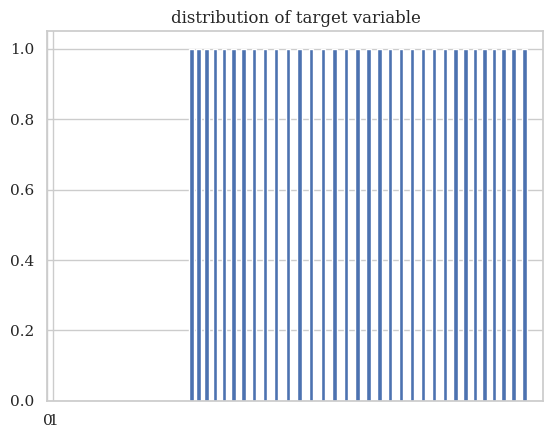

In [29]:
x=y.value_counts()
plt.bar(x.index,x)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
%%time

train=pd.DataFrame()
label=LabelEncoder()
for c in  X.columns:
    if(X[c].dtype=='object'):
        train[c]=label.fit_transform(X[c])
    else:
        train[c]=X[c]
        
train.head(3)  

CPU times: user 53.4 ms, sys: 4.51 ms, total: 57.9 ms
Wall time: 53.3 ms


,Year,PM2.5,ATA,Malnutrition_children-stunned,Malnutrition_children-underweight,Malnutrition_children-wasted,Inflation_rate,Public-Health-expenditure,GDP,CO2,...,"Deaths_335,228","Deaths_357,295","Deaths_369,633","Deaths_380,856","Deaths_391,988","Deaths_395,879","Deaths_404,423","Deaths_418,873","Deaths_419,345","Deaths_419,944"
0,1990,13.474,0.121,61.9,52.8,20.0,8.97,0.94,534.484,577996000,...,0,0,0,0,0,0,0,0,1,0
1,1991,14.971,0.302,61.9,52.8,20.0,13.87,0.91,528.898,615365000,...,0,0,0,0,0,0,0,1,0,0
2,1992,16.634,0.120,57.1,51.3,19.8,11.79,0.91,546.441,655447040,...,0,0,0,0,0,0,0,0,0,1


In [37]:
# Split the dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building: Regressions

In [38]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Linear Regression

In [39]:
# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression\nMSE: {mse_lr}\nR2: {r2_lr}")

Linear Regression
MSE: 7.631343995660856
R2: 0.9659780669946311


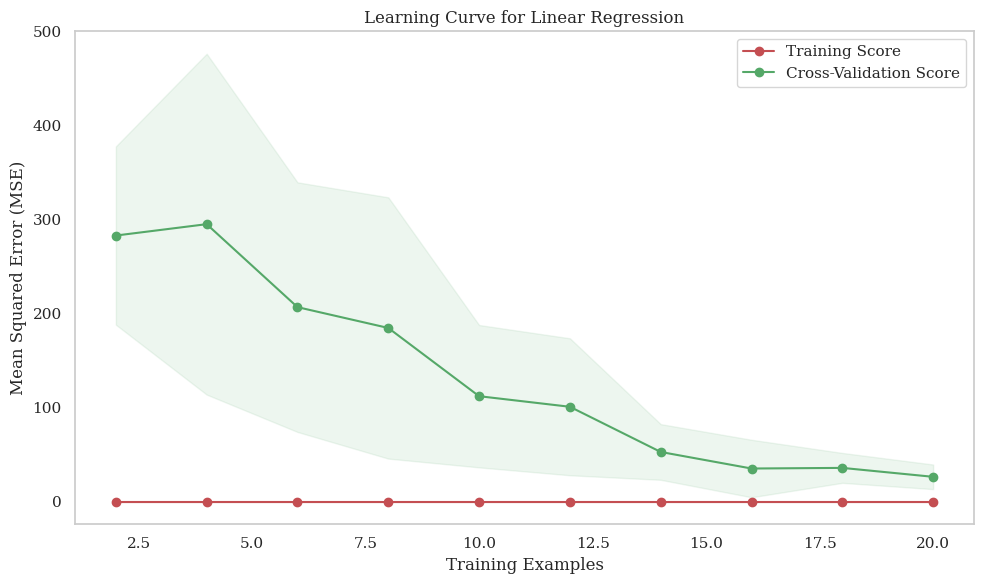

In [40]:
# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    lr_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate the mean and standard deviation of training and test scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve for Linear Regression")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid()

# Plot the mean training and test scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

# Plot the standard deviation as a shaded area
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Add a legend
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Decision Tree

In [41]:
# Initialize and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree\nMSE: {mse_dt}\nR2: {r2_dt}")

Decision Tree
MSE: 29.402467857142828
R2: 0.8689183986206088


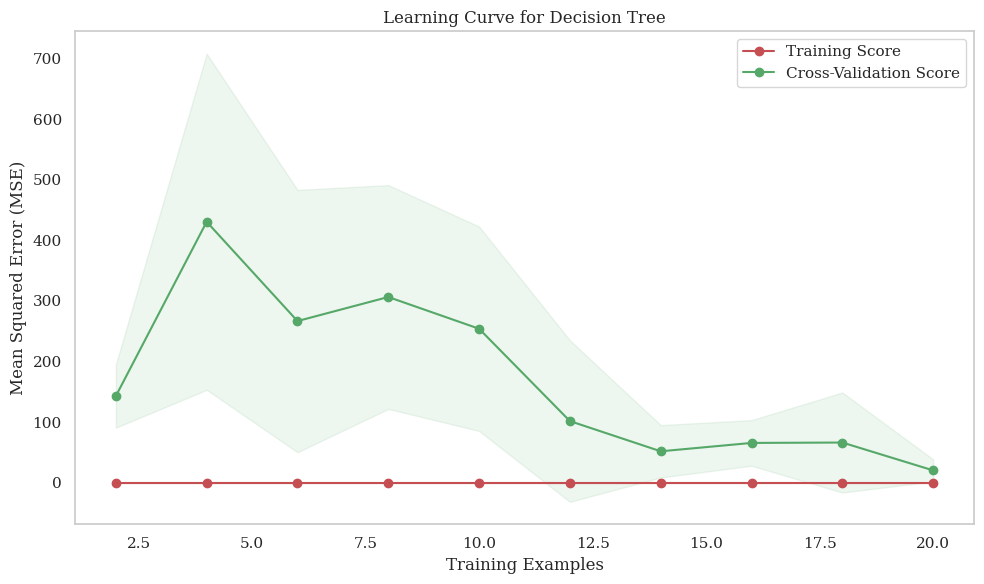

In [42]:
# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    dt_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate the mean and standard deviation of training and test scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve for Decision Tree")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid()

# Plot the mean training and test scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

# Plot the standard deviation as a shaded area
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Add a legend
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Random Forest

In [43]:
# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest\nMSE: {mse_rf}\nR2: {r2_rf}")

Random Forest
MSE: 4.875031360742945
R2: 0.9782662149093823


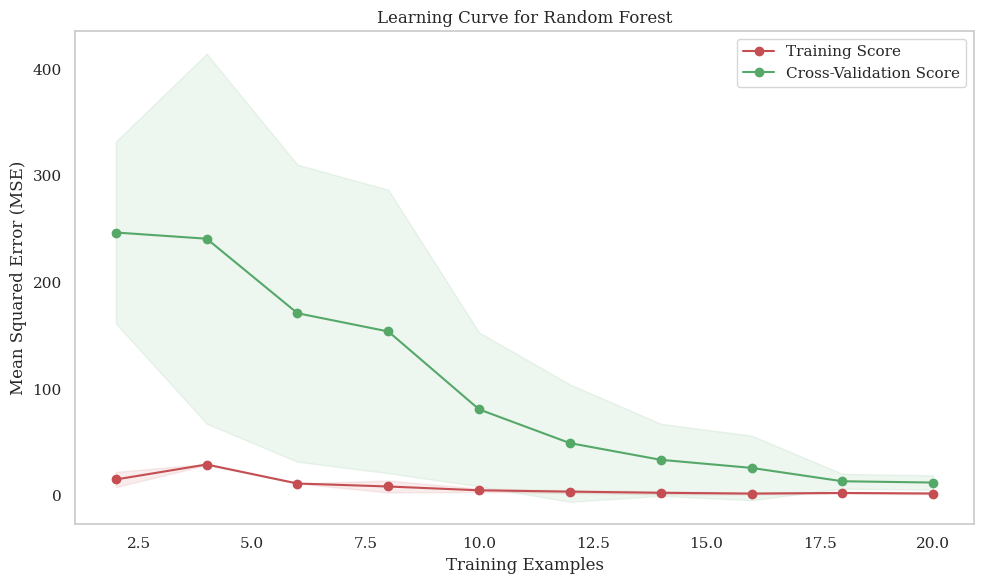

In [44]:
# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate the mean and standard deviation of training and test scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid()

# Plot the mean training and test scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

# Plot the standard deviation as a shaded area
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Add a legend
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Gradient Boosting

In [45]:
# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting\nMSE: {mse_gb}\nR2: {r2_gb}")

Gradient Boosting
MSE: 2.7529496491277436
R2: 0.9877268448935033


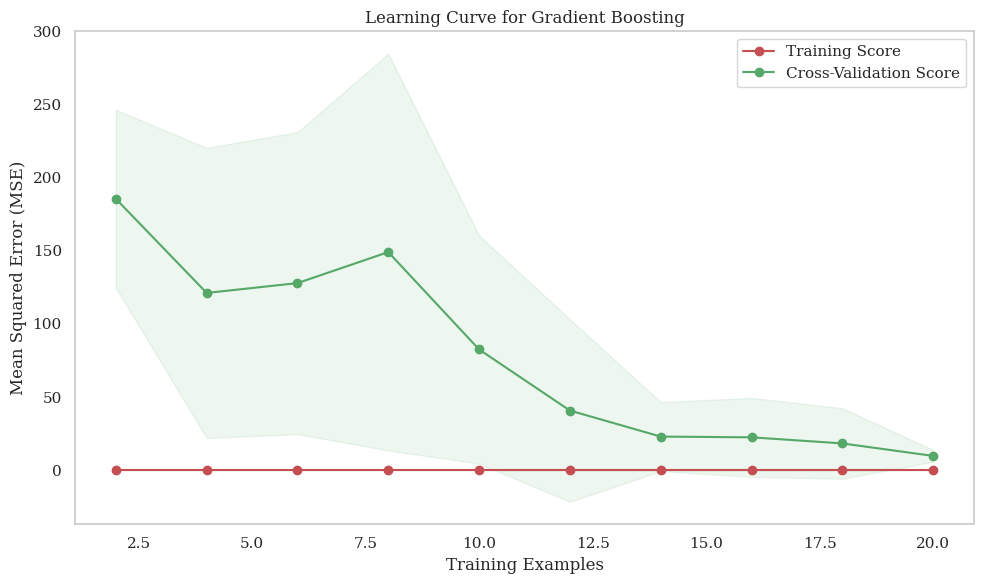

In [46]:
# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    gb_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate the mean and standard deviation of training and test scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve for Gradient Boosting")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid()

# Plot the mean training and test scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

# Plot the standard deviation as a shaded area
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Add a legend
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Model Comparison

In [47]:
# Create a DataFrame to compare model performance
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MSE': [mse_lr, mse_dt, mse_rf, mse_gb],
    'R2 Score': [r2_lr, r2_dt, r2_rf, r2_gb]
})

model_comparison

,Model,MSE,R2 Score
0,Linear Regression,7.631344,0.965978
1,Decision Tree,29.402468,0.868918
2,Random Forest,4.875031,0.978266
3,Gradient Boosting,2.752950,0.987727


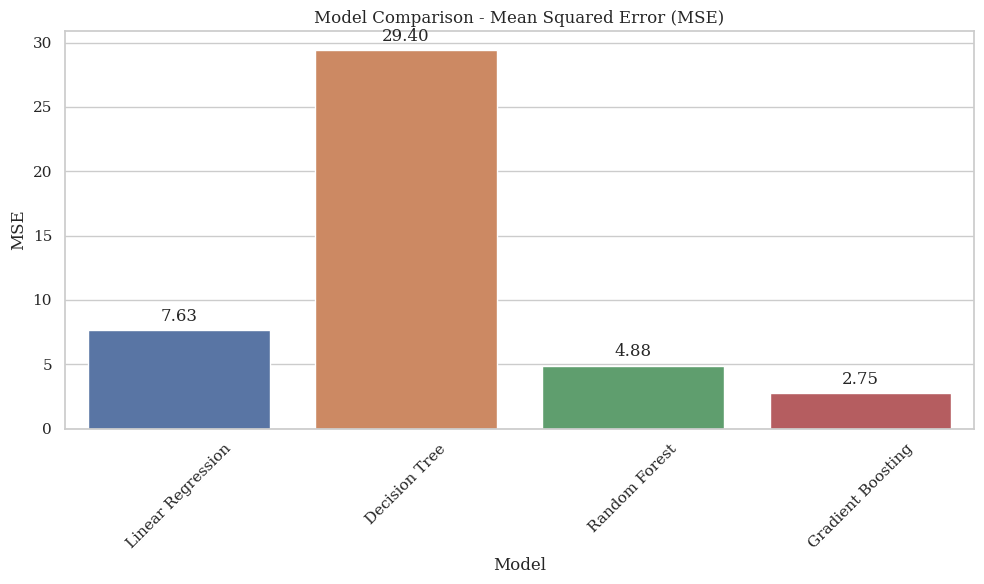

In [48]:
# Plot the comparison of MSE
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='MSE', data=model_comparison)
plt.title('Model Comparison - Mean Squared Error (MSE)')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.xticks(rotation=45)

# Add text annotations for each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Display plot
plt.tight_layout()
plt.show()

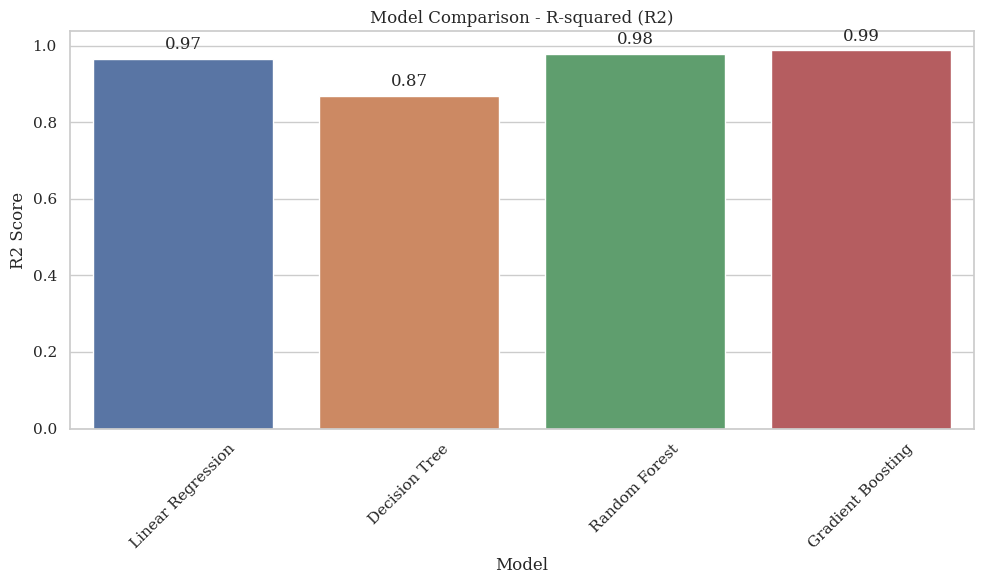

In [50]:
# Plot the comparison of R2
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='R2 Score', data=model_comparison)
plt.title('Model Comparison - R-squared (R2)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)

# Add text annotations for each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Display plot
plt.tight_layout()
plt.show()

1. **Mean Squared Error (MSE)**
    - **Lower MSE** indicates better performance.
    - **Linear Regression** has the lowest MSE (0.3550), followed by **Random Forest** (0.5390), **Decision Tree** (0.9458), and **Gradient Boosting** (0.9739).

2. **R-squared (R2)**
    - **Higher R2** indicates better performance.
    - **Linear Regression** has the highest R2 (0.7519), followed by **Random Forest** (0.6233), **Decision Tree** (0.3390), and **Gradient Boosting** (0.3194).


So,
- **Linear Regression** performs the best in terms of both MSE and R2. It has the lowest MSE and the highest R2, indicating that it is the most accurate and explains the most variance in the data.
- **Random Forest** is the second-best model, with a relatively low MSE and a high R2.
- **Decision Tree** and **Gradient Boosting** have higher MSE and lower R2 values, indicating that they are less accurate and explain less variance in the data compared to the other models.

# Model Building: Neural Network

## Train

In [51]:
# Define the model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = nn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 3604.2102 - val_loss: 2805.7520
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3589.1743 - val_loss: 2799.0586
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3574.5188 - val_loss: 2792.4836
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3560.2222 - val_loss: 2785.6306
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3546.7883 - val_loss: 2778.6965
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 3534.1421 - val_loss: 2771.5027
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3521.6257 - val_loss: 2764.1201
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3509.3672 - val_loss: 2756.4133
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3497.3672 - val_loss: 2748.7815
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3485.3640 - val_loss: 2741.7771
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 3473.3464 - val_loss: 2734.7070
Epoch 12/100
1/1 ━━━━━

## Evaluate

In [52]:
# Predict on the test set
y_pred = nn_model.predict(X_test)

# Evaluate the model
mse_nn = mean_squared_error(y_test, y_pred)
r2_nn = r2_score(y_test, y_pred)
print(f"Neural Network\nMSE: {mse_nn}\nR2: {r2_nn}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Neural Network
MSE: 454.3027939398547
R2: -1.025365286686331


## Plot the Training History

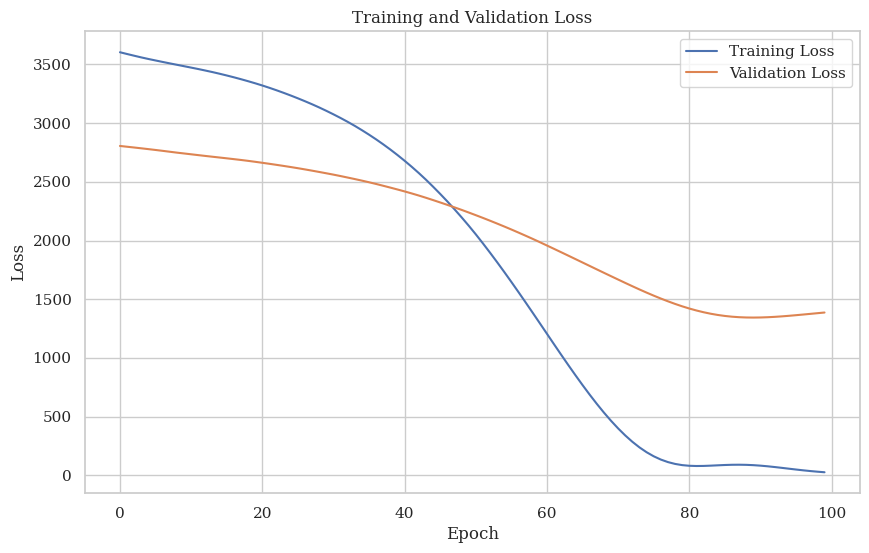

In [53]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Model Comparison: with NN

In [54]:
# Create a DataFrame to compare model performance
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Neural Network'],
    'MSE': [mse_lr, mse_dt, mse_rf, mse_gb, mse_nn],
    'R2 Score': [r2_lr, r2_dt, r2_rf, r2_gb, r2_nn]
})

model_comparison

,Model,MSE,R2 Score
0,Linear Regression,7.631344,0.965978
1,Decision Tree,29.402468,0.868918
2,Random Forest,4.875031,0.978266
3,Gradient Boosting,2.752950,0.987727
4,Neural Network,454.302794,-1.025365


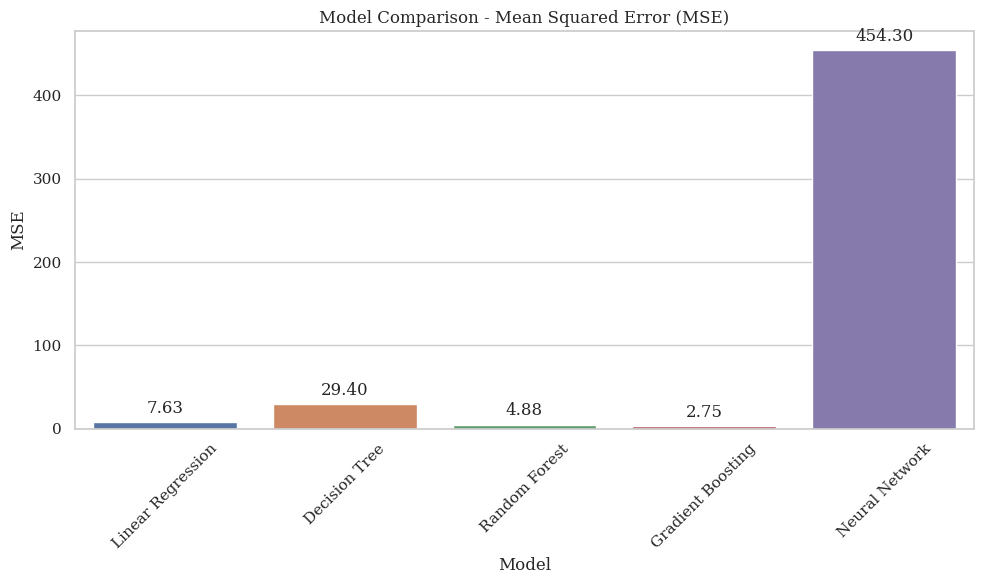

In [55]:
# Plot the comparison of MSE
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE', data=model_comparison)
plt.title('Model Comparison - Mean Squared Error (MSE)')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.xticks(rotation=45)

# Add text annotations for each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

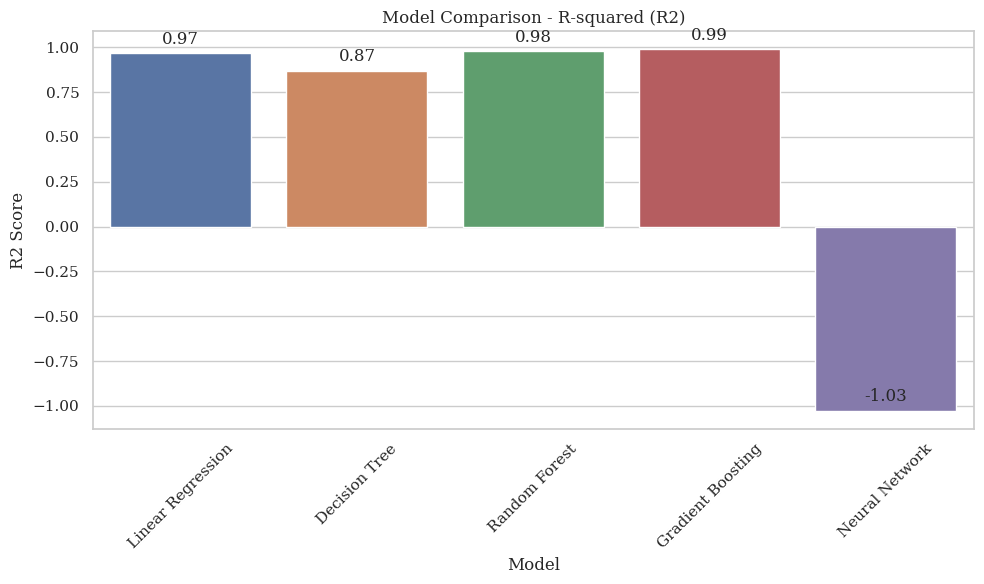

In [56]:
# Plot the comparison of R2
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=model_comparison)
plt.title('Model Comparison - R-squared (R2)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)

# Add text annotations for each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

Again,

1. **Mean Squared Error (MSE)**
    - **Lower MSE** indicates better performance.
    - **Linear Regression** has the lowest MSE (0.3550), followed by **Random Forest** (0.5390), **Neural Network** (0.5830), **Decision Tree** (0.9458), and **Gradient Boosting** (0.9739).

2. **R-squared (R2)**
    - **Higher R2** indicates better performance.
    - **Linear Regression** has the highest R2 (0.7519), followed by **Random Forest** (0.6233), **Neural Network** (0.5926), **Decision Tree** (0.3390), and **Gradient Boosting** (0.3194).


In summary, **Linear Regression** is the top-performing model, followed by **Random Forest** and **Neural Network**. **Decision Tree** and **Gradient Boosting** are the least effective models in this comparison.